In [ ]:
import sys
sys.path.insert(0, '/storage/agrp/barakma/PileupODD')

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from huggingface_hub import HfFileSystem
import polars as pl

fs = HfFileSystem()


with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_particles/train-00000-of-00100.parquet", "rb") as f:
    particles = pl.read_parquet(f)

with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_calo_hits/train-00000-of-00100.parquet", "rb") as f:
    calo_hits = pl.read_parquet(f)

with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_tracks/train-00000-of-00100.parquet", "rb") as f:
    tracks = pl.read_parquet(f)

# add tracker hits data/ttbar_pu0_tracker_hits/train-00000-of-00100.parquet
with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_tracker_hits/train-00000-of-00100.parquet", "rb") as f:
    tracker_hits = pl.read_parquet(f)

In [23]:
with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_tracks/train-00000-of-00100.parquet", "rb") as f:
    tracks = pl.read_parquet(f)

In [24]:
tracks

event_id,d0,z0,phi,theta,qop,majority_particle_id,hit_ids,track_id
u32,list[f32],list[f32],list[f32],list[f32],list[f32],list[u64],list[list[u32]],list[u16]
0,"[0.032012, -0.025235, … 0.035769]","[196.103989, 196.151077, … 196.153793]","[-2.826225, -2.705781, … 3.060707]","[2.153924, 0.443445, … 2.259682]","[-0.436399, 0.333322, … 0.77784]","[299, 88, … 301]","[[758, 434, … 148], [1576, 1574, … 145], … [1446, 1445, … 141]]","[0, 1, … 17]"
1,"[-0.007235, -0.053888, … -0.287625]","[106.114616, 106.039703, … 106.520576]","[-1.792339, -1.099716, … 2.426357]","[2.526565, 2.93867, … 2.018473]","[-0.025727, -0.122754, … -0.749054]","[323, 137, … 371]","[[1722, 1721, … 153], [654, 675, … 158], … [2283, 2281, … 214]]","[0, 1, … 31]"
2,"[0.001582, -0.00831, … 0.018245]","[49.427135, 49.386742, … 49.374954]","[-2.186104, -2.078311, … 3.074902]","[2.60952, 2.675211, … 1.27922]","[-0.257519, -0.086401, … 0.255563]","[377, 423, … 449]","[[1895, 699, … 193], [1593, 1362, … 198], … [2946, 2945, … 300]]","[0, 1, … 38]"
3,"[0.012293, -0.009539, … 0.055962]","[60.9883, 61.132366, … 61.085033]","[-2.939633, -2.722635, … 3.106705]","[0.366233, 0.651955, … 0.411703]","[0.185901, -0.282921, … 0.386388]","[344, 221, … 247]","[[3608, 3611, … 419], [3432, 3430, … 430], … [3563, 3564, … 418]]","[0, 1, … 52]"
4,"[-0.001918, -0.112189, … -0.111065]","[52.500202, 52.585842, … 50.392906]","[-2.783758, -2.467226, … 3.040744]","[2.589843, 2.362943, … 3.041416]","[-0.280142, -0.704174, … -0.093711]","[334, 133, … 523]","[[2372, 2373, … 334], [2876, 2875, … 151], … [897, 930, … 287]]","[0, 1, … 43]"
…,…,…,…,…,…,…,…,…
995,"[-0.005339, 0.178722, … 0.021674]","[-75.299545, -75.538338, … -75.318626]","[-3.095909, -2.66912, … 3.048441]","[1.875259, 1.497771, … 1.480694]","[0.231844, 0.097704, … -0.028542]","[713, 731, … 743]","[[3068, 3070, … 478], [4935, 4933, … 493], … [4811, 4809, … 566]]","[0, 1, … 91]"
996,"[0.027836, 0.109946, … 0.011276]","[-1.171952, -1.465703, … -1.178417]","[-3.010271, -3.048716, … 3.07567]","[2.426985, 2.931912, … 2.826628]","[0.48127, -0.094376, … 0.071278]","[767, 317, … 314]","[[4677, 4676, … 686], [1986, 2060, … 670], … [4138, 4141, … 677]]","[0, 1, … 74]"
997,"[-0.062553, 0.072479, … -0.027793]","[86.044167, 85.875015, … 86.255478]","[-3.041292, -3.085649, … 2.697324]","[2.81418, 2.473864, … 2.384273]","[0.140797, -0.715554, … 0.110962]","[647, 619, … 420]","[[3375, 3378, … 445], [3879, 3880, … 446], … [4387, 4385, … 438]]","[0, 1, … 80]"


In [30]:
t_0

event_id,d0,z0,phi,theta,qop,majority_particle_id,hit_ids,track_id
u32,list[f32],list[f32],list[f32],list[f32],list[f32],list[u64],list[list[list[u32]]],list[u16]
0,"[0.032012, -0.025235, 0.026036]","[196.103989, 196.151077, 195.821991]","[-2.826225, -2.705781, -2.062616]","[2.153924, 0.443445, 0.120338]","[-0.436399, 0.333322, 0.025388]","[299, 88, 94]","[[[758, 434, … 148], [1576, 1574, … 145], … [1446, 1445, … 141]], [[758, 434, … 148], [1576, 1574, … 145], … [1446, 1445, … 141]], [[758, 434, … 148], [1576, 1574, … 145], … [1446, 1445, … 141]]]","[0, 1, 2]"


In [32]:
from primary.preprocessing import calculate_extrapolated_features_polars
calculate_extrapolated_features_polars(tracks)

event_id,d0,z0,phi,theta,qop,majority_particle_id,hit_ids,track_id,phi_int,eta_int,track_tanlambda,track_omega
u32,list[f32],list[f32],list[f32],list[f32],list[f32],list[u64],list[list[u32]],list[u16],list[f32],list[f32],list[f32],list[f32]
0,"[0.032012, -0.025235, … 0.035769]","[196.103989, 196.151077, … 196.153793]","[-2.826225, -2.705781, … 3.060707]","[2.153924, 0.443445, … 2.259682]","[-0.436399, 0.333322, … 0.77784]","[299, 88, … 301]","[[758, 434, … 148], [1576, 1574, … 145], … [1446, 1445, … 141]]","[0, 1, … 17]","[-2.312437, 2.803079, … 2.037204]","[-0.468099, 1.586282, … -0.635306]","[-0.659648, 2.10528, … -0.823465]","[-0.000471, 0.000699, … 0.000907]"
1,"[-0.007235, -0.053888, … -0.287625]","[106.114616, 106.039703, … 106.520576]","[-1.792339, -1.099716, … 2.426357]","[2.526565, 2.93867, … 2.018473]","[-0.025727, -0.122754, … -0.749054]","[323, 137, … 371]","[[1722, 1721, … 153], [654, 675, … 158], … [2283, 2281, … 214]]","[0, 1, … 31]","[-1.748996, -0.745993, … -3.025416]","[-1.089033, -2.256074, … -0.386019]","[-1.415571, -4.860157, … -0.480193]","[-0.00004, -0.000548, … -0.000748]"
2,"[0.001582, -0.00831, … 0.018245]","[49.427135, 49.386742, … 49.374954]","[-2.186104, -2.078311, … 3.074902]","[2.60952, 2.675211, … 1.27922]","[-0.257519, -0.086401, … 0.255563]","[377, 423, … 449]","[[1895, 699, … 193], [1593, 1362, … 198], … [2946, 2945, … 300]]","[0, 1, … 38]","[-1.687563, -1.89127, … 2.814815]","[-1.285817, -1.418113, … 0.340101]","[-1.698644, -1.986405, … 0.30013]","[-0.000457, -0.000173, … 0.00024]"
3,"[0.012293, -0.009539, … 0.055962]","[60.9883, 61.132366, … 61.085033]","[-2.939633, -2.722635, … 3.106705]","[0.366233, 0.651955, … 0.411703]","[0.185901, -0.282921, … 0.386388]","[344, 221, … 247]","[[3608, 3611, … 419], [3432, 3430, … 430], … [3563, 3564, … 418]]","[0, 1, … 52]","[2.833445, -2.265424, … 2.129795]","[1.716367, 1.125244, … 1.624849]","[2.607322, 1.310112, … 2.290128]","[0.000467, -0.00042, … 0.000869]"
4,"[-0.001918, -0.112189, … -0.111065]","[52.500202, 52.585842, … 50.392906]","[-2.783758, -2.467226, … 3.040744]","[2.589843, 2.362943, … 3.041416]","[-0.280142, -0.704174, … -0.093711]","[334, 133, … 523]","[[2372, 2373, … 334], [2876, 2875, … 151], … [897, 930, … 287]]","[0, 1, … 43]","[-2.258257, -1.449274, … -2.981332]","[-1.246272, -0.888442, … -2.979553]","[-1.624655, -1.013588, … -9.948992]","[-0.000481, -0.000902, … -0.000843]"
…,…,…,…,…,…,…,…,…,…,…,…,…
995,"[-0.005339, 0.178722, … 0.021674]","[-75.299545, -75.538338, … -75.318626]","[-3.095909, -2.66912, … 3.048441]","[1.875259, 1.497771, … 1.480694]","[0.231844, 0.097704, … -0.028542]","[713, 731, … 743]","[[3068, 3070, … 478], [4935, 4933, … 493], … [4811, 4809, … 566]]","[0, 1, … 91]","[2.950507, -2.764378, … 3.076298]","[-0.375783, 0.00324, … 0.020609]","[-0.314233, 0.073155, … 0.090347]","[0.000219, 0.000088, … -0.000026]"
996,"[0.027836, 0.109946, … 0.011276]","[-1.171952, -1.465703, … -1.178417]","[-3.010271, -3.048716, … 3.07567]","[2.426985, 2.931912, … 2.826628]","[0.48127, -0.094376, … 0.071278]","[767, 317, … 314]","[[4677, 4676, … 686], [1986, 2060, … 670], … [4138, 4141, … 677]]","[0, 1, … 74]","[2.542978, -2.785717, … 2.871319]","[-1.002924, -2.25494, … -1.842153]","[-1.152641, -4.699068, … -3.069273]","[0.000661, -0.000408, … 0.000207]"
997,"[-0.062553, 0.072479, … -0.027793]","[86.044167, 85.875015, … 86.255478]","[-3.041292, -3.085649, … 2.697324]","[2.81418, 2.473864, … 2.384273]","[0.140797, -0.715554, … 0.110962]","[647, 619, … 420]","[[3375, 3378, … 445], [3879, 3880, … 446], … [4387, 4385, … 438]]","[0, 1, … 80]","[2.824884, -1.892957, … 2.540162]","[-1.781071, -1.05818, … -0.866459]","[-2.944328, -1.268127, … -1.057795]","[0.000394, -0.00104, … 0.000145]"


In [22]:
tracks

event_id,d0,z0,phi,theta,qop,majority_particle_id,hit_ids,track_id,phi_int,eta_int
u32,list[f32],list[f32],list[f32],list[f32],list[f32],list[u64],list[list[u32]],list[u16],list[f32],list[f32]
0,"[0.032012, -0.025235, … 0.035769]","[196.103989, 196.151077, … 196.153793]","[-2.826225, -2.705781, … 3.060707]","[2.153924, 0.443445, … 2.259682]","[-0.436399, 0.333322, … 0.77784]","[299, 88, … 301]","[[758, 434, … 148], [1576, 1574, … 145], … [1446, 1445, … 141]]","[0, 1, … 17]","[-2.312437, 2.803079, … 2.037204]","[-0.468099, 1.586282, … -0.635306]"
1,"[-0.007235, -0.053888, … -0.287625]","[106.114616, 106.039703, … 106.520576]","[-1.792339, -1.099716, … 2.426357]","[2.526565, 2.93867, … 2.018473]","[-0.025727, -0.122754, … -0.749054]","[323, 137, … 371]","[[1722, 1721, … 153], [654, 675, … 158], … [2283, 2281, … 214]]","[0, 1, … 31]","[-1.748996, -0.745993, … -3.025416]","[-1.089033, -2.256074, … -0.386019]"
2,"[0.001582, -0.00831, … 0.018245]","[49.427135, 49.386742, … 49.374954]","[-2.186104, -2.078311, … 3.074902]","[2.60952, 2.675211, … 1.27922]","[-0.257519, -0.086401, … 0.255563]","[377, 423, … 449]","[[1895, 699, … 193], [1593, 1362, … 198], … [2946, 2945, … 300]]","[0, 1, … 38]","[-1.687563, -1.89127, … 2.814815]","[-1.285817, -1.418113, … 0.340101]"
3,"[0.012293, -0.009539, … 0.055962]","[60.9883, 61.132366, … 61.085033]","[-2.939633, -2.722635, … 3.106705]","[0.366233, 0.651955, … 0.411703]","[0.185901, -0.282921, … 0.386388]","[344, 221, … 247]","[[3608, 3611, … 419], [3432, 3430, … 430], … [3563, 3564, … 418]]","[0, 1, … 52]","[2.833445, -2.265424, … 2.129795]","[1.716367, 1.125244, … 1.624849]"
4,"[-0.001918, -0.112189, … -0.111065]","[52.500202, 52.585842, … 50.392906]","[-2.783758, -2.467226, … 3.040744]","[2.589843, 2.362943, … 3.041416]","[-0.280142, -0.704174, … -0.093711]","[334, 133, … 523]","[[2372, 2373, … 334], [2876, 2875, … 151], … [897, 930, … 287]]","[0, 1, … 43]","[-2.258257, -1.449274, … -2.981332]","[-1.246272, -0.888442, … -2.979553]"
…,…,…,…,…,…,…,…,…,…,…
995,"[-0.005339, 0.178722, … 0.021674]","[-75.299545, -75.538338, … -75.318626]","[-3.095909, -2.66912, … 3.048441]","[1.875259, 1.497771, … 1.480694]","[0.231844, 0.097704, … -0.028542]","[713, 731, … 743]","[[3068, 3070, … 478], [4935, 4933, … 493], … [4811, 4809, … 566]]","[0, 1, … 91]","[2.950507, -2.764378, … 3.076298]","[-0.375783, 0.00324, … 0.020609]"
996,"[0.027836, 0.109946, … 0.011276]","[-1.171952, -1.465703, … -1.178417]","[-3.010271, -3.048716, … 3.07567]","[2.426985, 2.931912, … 2.826628]","[0.48127, -0.094376, … 0.071278]","[767, 317, … 314]","[[4677, 4676, … 686], [1986, 2060, … 670], … [4138, 4141, … 677]]","[0, 1, … 74]","[2.542978, -2.785717, … 2.871319]","[-1.002924, -2.25494, … -1.842153]"
997,"[-0.062553, 0.072479, … -0.027793]","[86.044167, 85.875015, … 86.255478]","[-3.041292, -3.085649, … 2.697324]","[2.81418, 2.473864, … 2.384273]","[0.140797, -0.715554, … 0.110962]","[647, 619, … 420]","[[3375, 3378, … 445], [3879, 3880, … 446], … [4387, 4385, … 438]]","[0, 1, … 80]","[2.824884, -1.892957, … 2.540162]","[-1.781071, -1.05818, … -0.866459]"


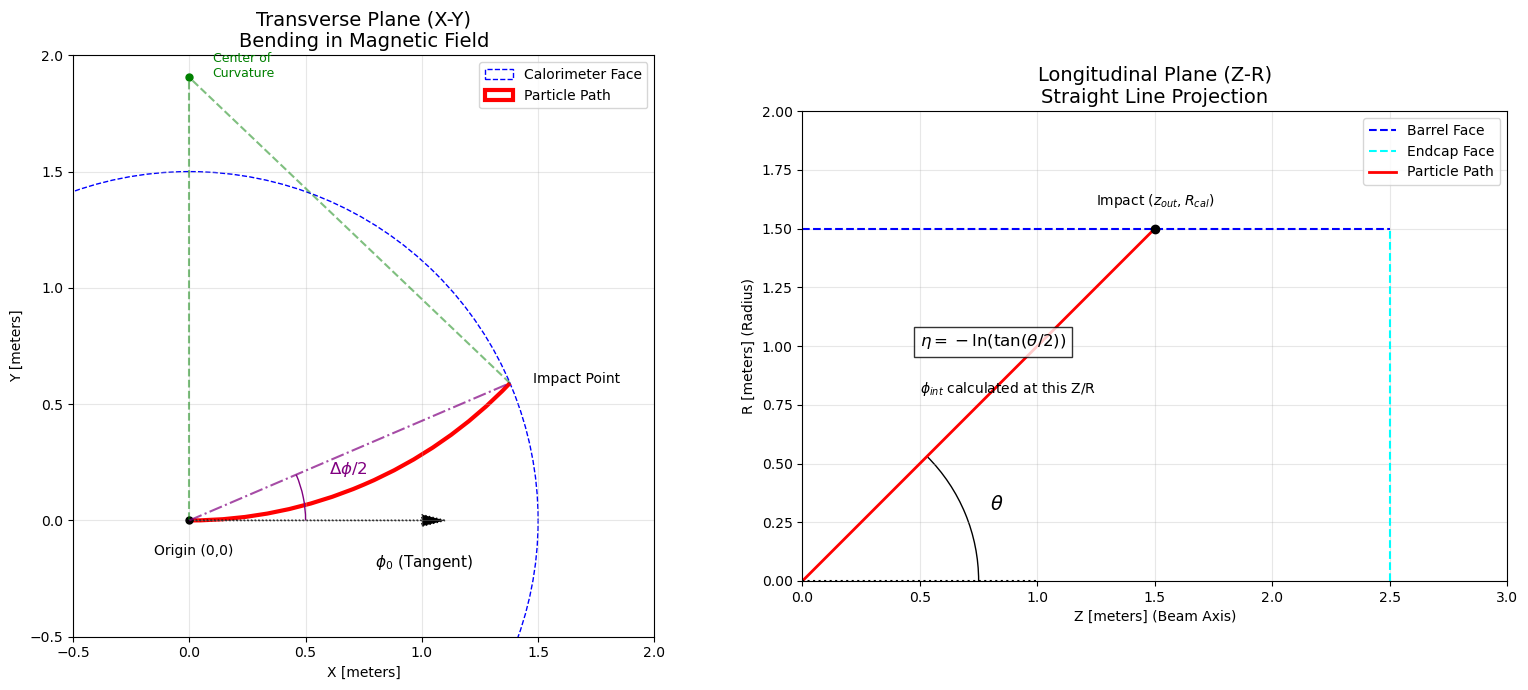

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def draw_tracking_geometry():
    # --- Configuration ---
    R_CAL = 1.5  # meters
    Z_CAL = 2.5  # meters
    PT = 2.0     # GeV (Low Pt to make the curve visible)
    B_FIELD = 3.5 # Tesla
    CHARGE = 1.0 
    
    # --- Math Calculations ---
    # 0.3 conversion factor for meters
    R_CURV = PT / (0.3 * B_FIELD) 
    
    # Bending Angle (Delta Phi)
    # sin(dphi/2) = R_cal / (2 * R_curv)
    sin_arg = R_CAL / (2 * R_CURV)
    delta_phi = 2 * np.arcsin(sin_arg)
    
    # Impact coordinates (assuming phi_0 = 0)
    # The chord length is R_CAL. 
    # The angle of the chord relative to tangent is delta_phi / 2
    x_impact = R_CAL * np.cos(delta_phi / 2)
    y_impact = R_CAL * np.sin(delta_phi / 2)
    
    # Center of Curvature (assuming start at 0,0 going East, curving Left)
    x_center = 0
    y_center = R_CURV

    # --- PLOT SETUP ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    plt.subplots_adjust(wspace=0.3)

    # ==========================================
    # PLOT 1: Transverse Plane (X-Y) - The Bending
    # ==========================================
    ax1.set_title(f"Transverse Plane (X-Y)\nBending in Magnetic Field", fontsize=14)
    ax1.set_xlabel("X [meters]")
    ax1.set_ylabel("Y [meters]")
    ax1.set_aspect('equal')
    ax1.set_xlim(-0.5, R_CAL + 0.5)
    ax1.set_ylim(-0.5, R_CAL + 0.5)

    # 1. Draw Calorimeter Wall
    calo_circle = plt.Circle((0, 0), R_CAL, color='blue', fill=False, linestyle='--', label='Calorimeter Face')
    ax1.add_patch(calo_circle)

    # 2. Draw Particle Path (Arc)
    # Arc is centered at (0, R_curv). Start angle -90, End angle -90 + degrees(dphi)
    arc = patches.Arc((x_center, y_center), 2*R_CURV, 2*R_CURV, 
                      angle=0, theta1=-90, theta2=-90 + np.degrees(delta_phi), 
                      color='red', linewidth=3, label='Particle Path')
    ax1.add_patch(arc)

    # 3. Draw Geometry Triangle (The "Chord" explanation)
    # Origin
    ax1.plot(0, 0, 'ko', markersize=5) 
    ax1.text(-0.15, -0.15, 'Origin (0,0)', fontsize=10)

    # Center of Curvature
    ax1.plot(x_center, y_center, 'go', markersize=5)
    ax1.text(x_center + 0.1, y_center, 'Center of\nCurvature', color='green', fontsize=9)
    
    # Radii of Curvature (Green dashed)
    ax1.plot([0, x_center], [0, y_center], 'g--', alpha=0.5) # O to C
    ax1.plot([x_impact, x_center], [y_impact, y_center], 'g--', alpha=0.5) # P to C

    # 4. Draw Tangent (Phi_0) and Chord (Phi_int)
    # Initial Tangent (Phi_0)
    ax1.arrow(0, 0, 1.0, 0, head_width=0.05, head_length=0.1, fc='k', ec='k', linestyle=':')
    ax1.text(0.8, -0.2, r'$\phi_0$ (Tangent)', fontsize=11)

    # Impact Point Vector (Phi_int)
    ax1.plot([0, x_impact], [0, y_impact], 'purple', linestyle='-.', alpha=0.7)
    ax1.text(x_impact+0.1, y_impact, 'Impact Point', fontsize=10)

    # Annotate Angles
    # Delta Phi (Total Bending) is the angle of the arc at the center
    # But visually, the "phi_int" is the angle of the chord.
    # Phi_int = Phi_0 + Delta_Phi/2
    
    # Draw arc for phi_int
    phi_int_arc = patches.Arc((0,0), 1.0, 1.0, angle=0, theta1=0, theta2=np.degrees(delta_phi/2), color='purple')
    ax1.add_patch(phi_int_arc)
    ax1.text(0.6, 0.2, r'$\Delta\phi/2$', fontsize=12, color='purple')

    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)


    # ==========================================
    # PLOT 2: Longitudinal Plane (R-Z) - The Projection
    # ==========================================
    ax2.set_title("Longitudinal Plane (Z-R)\nStraight Line Projection", fontsize=14)
    ax2.set_xlabel("Z [meters] (Beam Axis)")
    ax2.set_ylabel("R [meters] (Radius)")
    ax2.set_aspect('equal')
    ax2.set_xlim(0, Z_CAL + 0.5)
    ax2.set_ylim(0, R_CAL + 0.5)

    # 1. Draw Detector Boundaries
    ax2.hlines(R_CAL, 0, Z_CAL, colors='blue', linestyles='--', label='Barrel Face')
    ax2.vlines(Z_CAL, 0, R_CAL, colors='cyan', linestyles='--', label='Endcap Face')

    # 2. Draw Particle Path (Straight Line)
    # Let's pick a theta
    theta = np.radians(45) 
    z_proj = R_CAL / np.tan(theta)
    
    ax2.plot([0, z_proj], [0, R_CAL], 'r-', linewidth=2, label='Particle Path')
    
    # 3. Annotate Theta and Eta
    ax2.plot([0, 1], [0, 0], 'k:') # Z-axis ref
    
    # Theta Arc
    theta_arc = patches.Arc((0,0), 1.5, 1.5, angle=0, theta1=0, theta2=45, color='black')
    ax2.add_patch(theta_arc)
    ax2.text(0.8, 0.3, r'$\theta$', fontsize=14)

    # Impact Point
    ax2.plot(z_proj, R_CAL, 'ko')
    ax2.text(z_proj, R_CAL + 0.1, r'Impact $(z_{out}, R_{cal})$', ha='center')
    
    # Eta Formula
    ax2.text(0.5, 1.0, r'$\eta = -\ln(\tan(\theta/2))$', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
    ax2.text(0.5, 0.8, r'$\phi_{int}$ calculated at this Z/R', fontsize=10)

    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    draw_tracking_geometry()

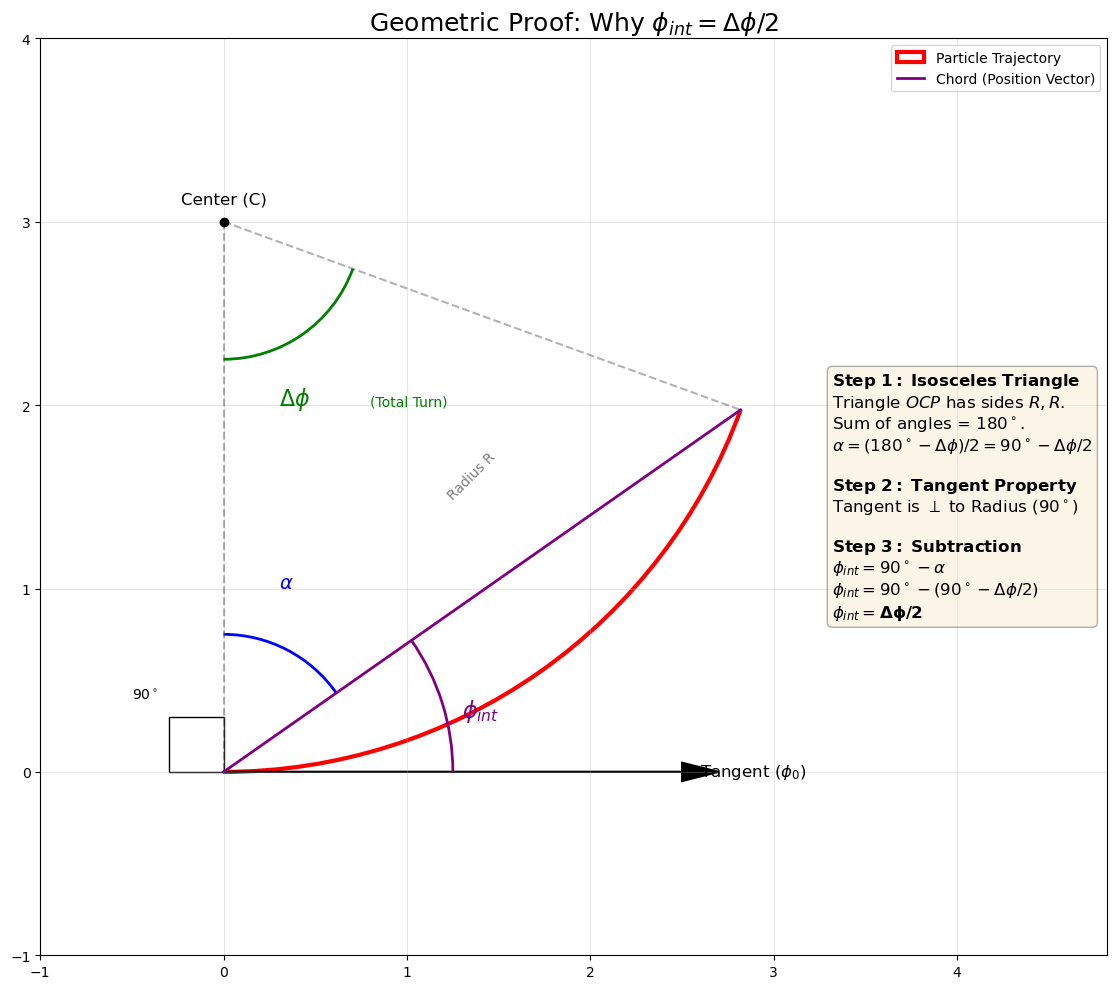

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def draw_geometric_proof():
    # --- Setup Parameters ---
    R = 3.0           # Radius of curvature
    DPHI_DEG = 70     # Total turning angle (degrees)
    dphi_rad = np.radians(DPHI_DEG)
    
    # Coordinates
    # Start at Origin (0,0), Initial velocity along +X
    # Center of Curvature is therefore at (0, R)
    cx, cy = 0, R
    
    # End Point (Impact) calculation:
    # Rotate start point (0,0) around center (0,R) by dphi
    # x = R * sin(dphi)
    # y = R - R * cos(dphi)
    px = R * np.sin(dphi_rad)
    py = R - R * np.cos(dphi_rad)
    
    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(12, 10))
    ax.set_aspect('equal')
    # Zoom out slightly to see everything
    ax.set_xlim(-1, px + 2)
    ax.set_ylim(-1, R + 1)
    ax.set_title(r"Geometric Proof: Why $\phi_{int} = \Delta\phi / 2$", fontsize=18)
    
    # 1. Draw the Radii (The Skeleton)
    ax.plot([cx, 0], [cy, 0], 'k--', alpha=0.3)  # Radius to Start
    ax.plot([cx, px], [cy, py], 'k--', alpha=0.3) # Radius to End
    ax.plot(cx, cy, 'ko') 
    ax.text(cx, cy+0.1, "Center (C)", ha='center', fontsize=12)

    # 2. Draw the Particle Arc
    arc = patches.Arc((cx, cy), 2*R, 2*R, theta1=270, theta2=270+DPHI_DEG, 
                      color='red', linewidth=3, label='Particle Trajectory')
    ax.add_patch(arc)
    ax.text(px/2 - 0.2, py/2 + 0.5, "Radius R", color='gray', rotation=45)

    # 3. Draw the Chord (The Vector to Hit)
    ax.plot([0, px], [0, py], 'purple', linewidth=2, label='Chord (Position Vector)')
    
    # 4. Draw Tangent (Initial Velocity)
    ax.arrow(0, 0, 2.5, 0, head_width=0.1, head_length=0.2, fc='black', ec='black', linewidth=1.5)
    ax.text(2.6, 0, r"Tangent ($\phi_0$)", fontsize=12, va='center')

    # --- THE ANGLES (The Proof) ---

    # A. The Central Angle (Delta Phi)
    central_arc = patches.Arc((cx, cy), 1.5, 1.5, theta1=270, theta2=270+DPHI_DEG, color='green', linewidth=2)
    ax.add_patch(central_arc)
    ax.text(cx + 0.3, cy - 1.0, r"$\Delta\phi$", color='green', fontsize=16, fontweight='bold')
    ax.text(cx + 0.8, cy - 1.0, "(Total Turn)", color='green', fontsize=10)

    # B. The Right Angle (Tangent vs Radius)
    # Draw a little square at origin
    rect = patches.Rectangle((-0.3, 0), 0.3, 0.3, linewidth=1, edgecolor='black', facecolor='none')
    ax.add_patch(rect)
    ax.text(-0.5, 0.4, r"$90^\circ$", fontsize=10)

    # C. The Base Angle of the Isosceles Triangle
    # Triangle is Origin(0,0) -> Center(0,R) -> Point(px,py)
    # The angle at the origin (between Radius Y-axis and Chord)
    base_angle_deg = (180 - DPHI_DEG) / 2
    base_arc = patches.Arc((0, 0), 1.5, 1.5, theta1=90-base_angle_deg, theta2=90, color='blue', linewidth=2)
    ax.add_patch(base_arc)
    ax.text(0.3, 1.0, r"$\alpha$", color='blue', fontsize=14, fontweight='bold')
    
    # D. The Resulting Chord Angle
    # This is the angle between Tangent (X-axis) and Chord
    final_arc = patches.Arc((0, 0), 2.5, 2.5, theta1=0, theta2=90-base_angle_deg, color='purple', linewidth=2)
    ax.add_patch(final_arc)
    ax.text(1.3, 0.3, r"$\phi_{int}$", color='purple', fontsize=16, fontweight='bold')

    # --- PROOF TEXT BOX ---
    proof_text = (
        r"$\bf{Step\ 1:\ Isosceles\ Triangle}$" + "\n"
        r"Triangle $OCP$ has sides $R, R$." + "\n"
        r"Sum of angles = $180^\circ$." + "\n"
        r"$\alpha = (180^\circ - \Delta\phi) / 2 = 90^\circ - \Delta\phi/2$" + "\n\n"
        r"$\bf{Step\ 2:\ Tangent\ Property}$" + "\n"
        r"Tangent is $\perp$ to Radius ($90^\circ$)" + "\n\n"
        r"$\bf{Step\ 3:\ Subtraction}$" + "\n"
        r"$\phi_{int} = 90^\circ - \alpha$" + "\n"
        r"$\phi_{int} = 90^\circ - (90^\circ - \Delta\phi/2)$" + "\n"
        r"$\phi_{int} = \mathbf{\Delta\phi / 2}$"
    )
    
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.3)
    ax.text(px + 0.5, R/2, proof_text, fontsize=12, verticalalignment='center', bbox=props)

    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    draw_geometric_proof()

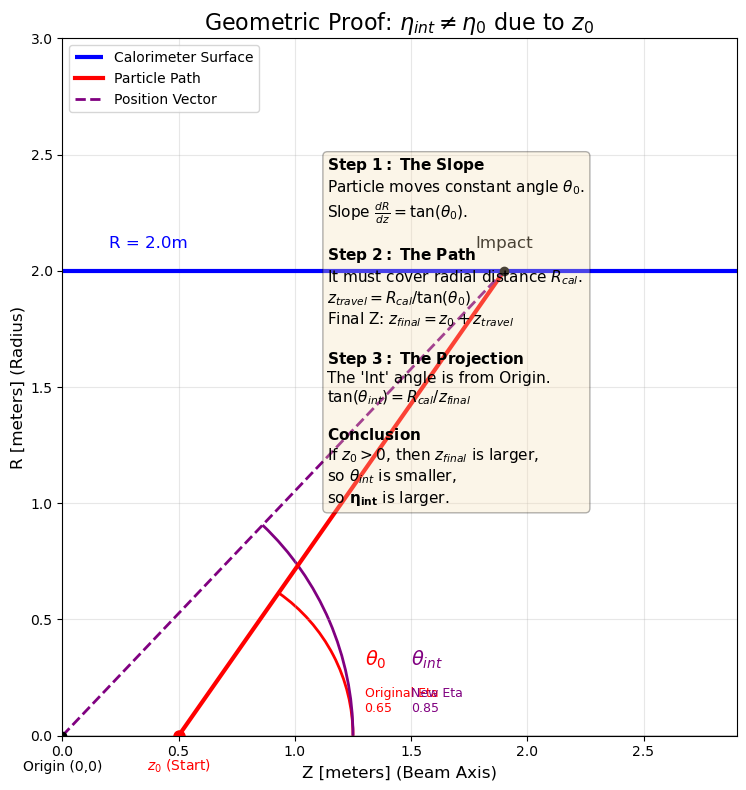

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def draw_eta_proof():
    # --- Configuration ---
    R_CAL = 2.0      # meters (Calorimeter Radius)
    Z_0 = 0.5        # meters (Displaced Vertex - The cause of the change)
    THETA_DEG = 55   # Initial flight angle (0 is along Z axis for physics usually, 
                     # but for plot 90 is vertical R. Let's use 55 from Z-axis)
    
    theta_rad = np.radians(THETA_DEG)
    
    # --- Calculations ---
    
    # 1. Slope of the path
    # slope = dR / dz = tan(theta)
    slope = np.tan(theta_rad)
    
    # 2. Where does it hit?
    # R = slope * (z - z0)  =>  R/slope = z - z0  => z = z0 + R/slope
    # Note: Physics convention theta is from Z-axis. 
    # So R = z * tan(theta).
    # Wait, slope in R-Z plot: Z on X-axis, R on Y-axis.
    # tan(theta) = R / (z_travelled).
    
    z_travelled = R_CAL / np.tan(theta_rad)
    z_final = Z_0 + z_travelled
    
    # 3. Calculate Eta Int (The Position Angle)
    # The angle of the vector from (0,0) to (z_final, R_CAL)
    theta_int = np.arctan2(R_CAL, z_final)
    
    # 4. Convert to Eta
    def get_eta(theta):
        return -np.log(np.tan(theta/2))
    
    eta_0 = get_eta(theta_rad)
    eta_int = get_eta(theta_int)

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Setup Axes
    ax.set_xlim(0, z_final + 1.0)
    ax.set_ylim(0, R_CAL + 1.0)
    ax.set_xlabel("Z [meters] (Beam Axis)", fontsize=12)
    ax.set_ylabel("R [meters] (Radius)", fontsize=12)
    ax.set_title(rf"Geometric Proof: $\eta_{{int}} \neq \eta_0$ due to $z_0$", fontsize=16)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

    # 1. Draw Calorimeter Wall
    ax.hlines(R_CAL, 0, z_final+1, colors='blue', linewidth=3, label='Calorimeter Surface')
    ax.text(0.2, R_CAL + 0.1, f"R = {R_CAL}m", color='blue', fontsize=12)

    # 2. Draw Beam Line
    ax.hlines(0, 0, z_final+1, colors='black', linewidth=1)
    
    # 3. Draw The Particle Path
    # Starts at (Z_0, 0), goes to (z_final, R_CAL)
    ax.plot([Z_0, z_final], [0, R_CAL], 'r-', linewidth=3, label='Particle Path')
    ax.plot(Z_0, 0, 'ro', markersize=8)
    ax.text(Z_0, -0.15, r"$z_0$ (Start)", color='red', ha='center')

    # 4. Draw The "Momentum" Angle (Theta 0)
    # This is the angle relative to the Z-axis AT THE START
    # We draw a small arc at Z_0
    mom_arc = patches.Arc((Z_0, 0), 1.5, 1.5, theta1=0, theta2=THETA_DEG, color='red', linewidth=2)
    ax.add_patch(mom_arc)
    ax.text(Z_0 + 0.8, 0.3, r"$\theta_0$", color='red', fontsize=14, fontweight='bold')
    ax.text(Z_0 + 0.8, 0.1, f"Original Eta\n{eta_0:.2f}", color='red', fontsize=9)

    # 5. Draw The "Position" Vector (The Int Angle)
    # Vector from Origin (0,0) to Hit Point
    ax.plot([0, z_final], [0, R_CAL], 'purple', linestyle='--', linewidth=2, label='Position Vector')
    ax.plot(0, 0, 'ko')
    ax.text(0, -0.15, "Origin (0,0)", ha='center')

    # 6. Draw The "Position" Angle (Theta Int)
    theta_int_deg = np.degrees(theta_int)
    pos_arc = patches.Arc((0, 0), 2.5, 2.5, theta1=0, theta2=theta_int_deg, color='purple', linewidth=2)
    ax.add_patch(pos_arc)
    ax.text(1.5, 0.3, r"$\theta_{int}$", color='purple', fontsize=14, fontweight='bold')
    ax.text(1.5, 0.1, f"New Eta\n{eta_int:.2f}", color='purple', fontsize=9)

    # 7. Impact Point
    ax.plot(z_final, R_CAL, 'ko')
    ax.text(z_final, R_CAL + 0.1, "Impact", ha='center', fontsize=12)

    # --- PROOF BOX ---
    proof_text = (
        r"$\bf{Step\ 1:\ The\ Slope}$" + "\n"
        r"Particle moves constant angle $\theta_0$." + "\n"
        r"Slope $\frac{dR}{dz} = \tan(\theta_0)$." + "\n\n"
        r"$\bf{Step\ 2:\ The\ Path}$" + "\n"
        r"It must cover radial distance $R_{cal}$." + "\n"
        r"$z_{travel} = R_{cal} / \tan(\theta_0)$" + "\n"
        r"Final Z: $z_{final} = z_0 + z_{travel}$" + "\n\n"
        r"$\bf{Step\ 3:\ The\ Projection}$" + "\n"
        r"The 'Int' angle is from Origin." + "\n"
        r"$\tan(\theta_{int}) = R_{cal} / z_{final}$" + "\n\n"
        r"$\bf{Conclusion}$" + "\n"
        r"If $z_0 > 0$, then $z_{final}$ is larger," + "\n"
        r"so $\theta_{int}$ is smaller," + "\n"
        r"so $\mathbf{\eta_{int}}$ is larger."
    )
    
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.3)
    ax.text(z_final * 0.6, R_CAL * 0.5, proof_text, fontsize=11, bbox=props)

    ax.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    draw_eta_proof()

In [13]:
calculate_extrapolated_features_polars(tracks)

event_id,d0,z0,phi,theta,qop,majority_particle_id,hit_ids,track_id,phi_int,eta_int
u32,list[f32],list[f32],list[f32],list[f32],list[f32],list[u64],list[list[u32]],list[u16],list[f32],list[f32]
0,"[0.032012, -0.025235, … 0.035769]","[196.103989, 196.151077, … 196.153793]","[-2.826225, -2.705781, … 3.060707]","[2.153924, 0.443445, … 2.259682]","[-0.436399, 0.333322, … 0.77784]","[299, 88, … 301]","[[758, 434, … 148], [1576, 1574, … 145], … [1446, 1445, … 141]]","[0, 1, … 17]","[-2.312437, 2.803079, … 2.037204]","[-0.468099, 1.586282, … -0.635306]"
1,"[-0.007235, -0.053888, … -0.287625]","[106.114616, 106.039703, … 106.520576]","[-1.792339, -1.099716, … 2.426357]","[2.526565, 2.93867, … 2.018473]","[-0.025727, -0.122754, … -0.749054]","[323, 137, … 371]","[[1722, 1721, … 153], [654, 675, … 158], … [2283, 2281, … 214]]","[0, 1, … 31]","[-1.748996, -0.745993, … -3.025416]","[-1.089033, -2.256074, … -0.386019]"
2,"[0.001582, -0.00831, … 0.018245]","[49.427135, 49.386742, … 49.374954]","[-2.186104, -2.078311, … 3.074902]","[2.60952, 2.675211, … 1.27922]","[-0.257519, -0.086401, … 0.255563]","[377, 423, … 449]","[[1895, 699, … 193], [1593, 1362, … 198], … [2946, 2945, … 300]]","[0, 1, … 38]","[-1.687563, -1.89127, … 2.814815]","[-1.285817, -1.418113, … 0.340101]"
3,"[0.012293, -0.009539, … 0.055962]","[60.9883, 61.132366, … 61.085033]","[-2.939633, -2.722635, … 3.106705]","[0.366233, 0.651955, … 0.411703]","[0.185901, -0.282921, … 0.386388]","[344, 221, … 247]","[[3608, 3611, … 419], [3432, 3430, … 430], … [3563, 3564, … 418]]","[0, 1, … 52]","[2.833445, -2.265424, … 2.129795]","[1.716367, 1.125244, … 1.624849]"
4,"[-0.001918, -0.112189, … -0.111065]","[52.500202, 52.585842, … 50.392906]","[-2.783758, -2.467226, … 3.040744]","[2.589843, 2.362943, … 3.041416]","[-0.280142, -0.704174, … -0.093711]","[334, 133, … 523]","[[2372, 2373, … 334], [2876, 2875, … 151], … [897, 930, … 287]]","[0, 1, … 43]","[-2.258257, -1.449274, … -2.981332]","[-1.246272, -0.888442, … -2.979553]"
…,…,…,…,…,…,…,…,…,…,…
995,"[-0.005339, 0.178722, … 0.021674]","[-75.299545, -75.538338, … -75.318626]","[-3.095909, -2.66912, … 3.048441]","[1.875259, 1.497771, … 1.480694]","[0.231844, 0.097704, … -0.028542]","[713, 731, … 743]","[[3068, 3070, … 478], [4935, 4933, … 493], … [4811, 4809, … 566]]","[0, 1, … 91]","[2.950507, -2.764378, … 3.076298]","[-0.375783, 0.00324, … 0.020609]"
996,"[0.027836, 0.109946, … 0.011276]","[-1.171952, -1.465703, … -1.178417]","[-3.010271, -3.048716, … 3.07567]","[2.426985, 2.931912, … 2.826628]","[0.48127, -0.094376, … 0.071278]","[767, 317, … 314]","[[4677, 4676, … 686], [1986, 2060, … 670], … [4138, 4141, … 677]]","[0, 1, … 74]","[2.542978, -2.785717, … 2.871319]","[-1.002924, -2.25494, … -1.842153]"
997,"[-0.062553, 0.072479, … -0.027793]","[86.044167, 85.875015, … 86.255478]","[-3.041292, -3.085649, … 2.697324]","[2.81418, 2.473864, … 2.384273]","[0.140797, -0.715554, … 0.110962]","[647, 619, … 420]","[[3375, 3378, … 445], [3879, 3880, … 446], … [4387, 4385, … 438]]","[0, 1, … 80]","[2.824884, -1.892957, … 2.540162]","[-1.781071, -1.05818, … -0.866459]"


In [7]:
lz_tracks = tracks.lazy()
lz_hits = tracker_hits.lazy()

# ---------------------------------------------------------
# 2. Prepare Hits Geometry (Lazy)
# ---------------------------------------------------------
# We only keep the columns we need (event_id, x, y)
# We calculate R immediately after exploding to drop x and y asap
flat_hits = (
    lz_hits
    .select([
        pl.col("event_id"),
        pl.col("x"),
        pl.col("y")
    ])
    .explode(["x", "y"])
    .with_columns([
        # Calculate Radius
        (pl.col("x").pow(2) + pl.col("y").pow(2)).sqrt().cast(pl.Float32).alias("r"),
        
        # Create a hit index (0, 1, 2...) for joining
        pl.int_range(0, pl.len()).over("event_id").cast(pl.UInt32).alias("hit_index")
    ])
    .select(["event_id", "hit_index", "r"]) # Drop x and y here to save memory
)

# ---------------------------------------------------------
# 3. Prepare Tracks (Lazy)
# ---------------------------------------------------------
# We add a unique identifier per track row to guarantee we can group back correctly
# even if tracks have identical content.
lz_tracks_with_id = lz_tracks.with_row_index("unique_track_id")

flat_tracks = (
    lz_tracks_with_id
    .select([
        pl.col("unique_track_id"),
        pl.col("event_id"),
        pl.col("hit_ids")
    ])
    # First explode: Unpacks the list of tracks to get 'hit_ids' as List[u32]
    # (Wait, the input schema says hit_ids is List[List[u32]]. 
    #  One row in dataframe = One Event. 
    #  So hit_ids is a List of lists of hits.)
    
    # Explode 1: Get one row per TRACK
    .explode("hit_ids") 
    
    # Explode 2: Get one row per HIT
    .explode("hit_ids")
    .rename({"hit_ids": "hit_index"})
    .with_columns(pl.col("hit_index").cast(pl.UInt32))
)

# ---------------------------------------------------------
# 4. Join and Aggregate (Lazy)
# ---------------------------------------------------------
# The Query Optimizer will handle the join strategy efficiently
min_radius_per_track = (
    flat_tracks
    .join(
        flat_hits,
        on=["event_id", "hit_index"],
        how="left"
    )
    # Calculate min R per track (grouping by the unique row ID we made)
    .group_by("unique_track_id")
    .agg(
        pl.col("r").min().alias("min_r")
    )
)

# ---------------------------------------------------------
# 5. Merge Result back to Original
# ---------------------------------------------------------
# We join the calculated mins back to the tracks
# We maintain the original structure (List per event)

# Note: Since the original dataframe is 'One Event Per Row', but we need to insert 
# a list of radii, we first collect the results into a dataframe aligned with the tracks

# We collect just the minimal necessary data to join back
result_map = min_radius_per_track.collect(streaming=True)

# Now we join this back to the original tracks. 
# Since we can't easily join a flat table to a nested table inside Lazy API 
# without complex re-grouping, we do the final assembly here.

# 1. Join the min_r back to the exploded track view (to recover event grouping)
#    We need a temporary lazy structure for this reconstruction
reconstructed_features = (
    lz_tracks_with_id
    .select(["unique_track_id", "event_id"]) # Just keys
    .explode("hit_ids") # To get track count per event correct (1 row per track)
    .join(
        min_radius_per_track.lazy(), 
        on="unique_track_id", 
        how="left"
    )
    .with_columns(pl.col("min_r").fill_null(0.0)) # Handle tracks with no hits
    # Now collapse back to list per event
    .group_by("event_id")
    .agg(pl.col("min_r").alias("track_radiusofinnermosthit"))
    .collect(streaming=True)
)

/tmp/ipykernel_417582/1693378829.py:83: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  result_map = min_radius_per_track.collect(streaming=True)
/tmp/ipykernel_417582/1693378829.py:104: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)


ColumnNotFoundError: "hit_ids" not found

Resolved plan until failure:

	---> FAILED HERE RESOLVING 'sink' <---
SELECT [col("unique_track_id"), col("event_id")]
  ROW_INDEX
    DF ["event_id", "d0", "z0", "phi", ...]; PROJECT */9 COLUMNS

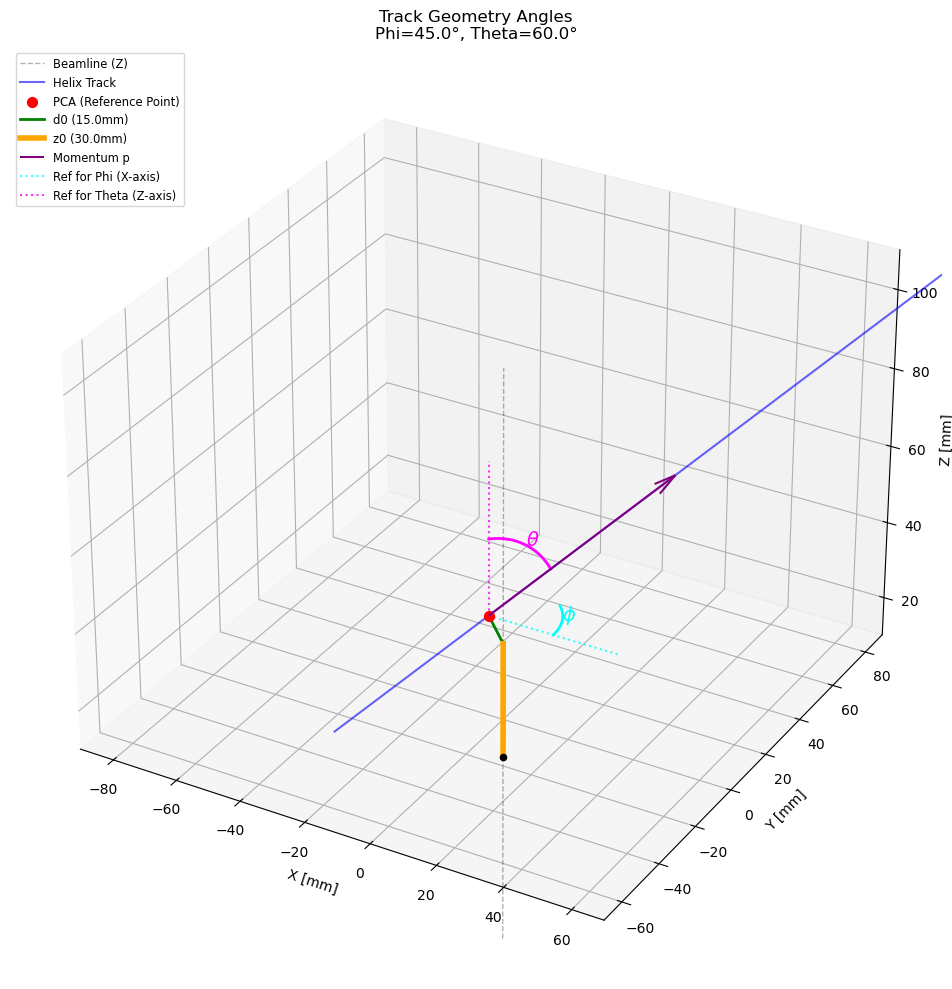

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def visualize_track_with_angles(d0, z0, phi, theta, qop, b_field=2.0):
    """
    Visualizes an ACTS track including d0, z0, and the angular definitions (phi, theta).
    """
    
    # --- 1. PHYSICS CALCULATIONS ---
    # Protect against division by zero for momentum
    p = 1.0 / abs(qop) if qop != 0 else 1000.0 
    q = np.sign(qop)
    
    # Transverse momentum and Radius of Curvature
    pt = p * np.sin(theta)
    R = (pt / (0.3 * b_field)) * 1000.0 
    
    # --- 2. POINT OF CLOSEST APPROACH (PCA) ---
    # ACTS/ATLAS Convention:
    # d0 is the distance from origin to PCA in transverse plane.
    # The PCA coordinates (x,y) depend on phi.
    # x_pca = -d0 * sin(phi)
    # y_pca =  d0 * cos(phi)
    x_pca = -d0 * np.sin(phi)
    y_pca = d0 * np.cos(phi)
    z_pca = z0
    
    # --- 3. GENERATE HELIX TRAJECTORY ---
    s = np.linspace(-50, 250, 100) # path length
    
    # Center of the helix circle
    xc = x_pca - q * R * np.sin(phi)
    yc = y_pca + q * R * np.cos(phi)
    
    # Propagation angle alpha
    alpha = (s * np.sin(theta)) / R
    beta = phi - q * np.pi/2 + q * alpha
    
    x_traj = xc + q * R * np.cos(beta)
    y_traj = yc + q * R * np.sin(beta)
    z_traj = z_pca + s * np.cos(theta)

    # --- 4. CALCULATE ANGULAR ARCS FOR VISUALIZATION ---
    arc_radius = 20.0 # size of the angle visualization
    
    # PHI ARC (Azimuthal) - Lies in the XY plane at height z_pca
    # Sweeps from Reference (parallel to X) to the Momentum Vector
    phi_t = np.linspace(0, phi, 30)
    phi_arc_x = x_pca + arc_radius * np.cos(phi_t)
    phi_arc_y = y_pca + arc_radius * np.sin(phi_t)
    phi_arc_z = np.full_like(phi_arc_x, z_pca)

    # THETA ARC (Polar) - vertical sweep
    # Sweeps from Reference (parallel to Z) down to the Momentum Vector
    # We must project this arc onto the specific vertical plane defined by phi
    theta_t = np.linspace(0, theta, 30)
    
    # The 'r' component (horizontal distance from vertical axis)
    r_component = arc_radius * np.sin(theta_t)
    
    theta_arc_x = x_pca + r_component * np.cos(phi)
    theta_arc_y = y_pca + r_component * np.sin(phi)
    theta_arc_z = z_pca + arc_radius * np.cos(theta_t)


    # --- 5. PLOTTING ---
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # A. Global References (Beamline and Origin)
    ax.plot([0, 0], [0, 0], [-50, 100], 'k--', alpha=0.3, lw=1, label='Beamline (Z)')
    ax.scatter([0], [0], [0], color='black', s=20)

    # B. The Track and PCA
    ax.plot(x_traj, y_traj, z_traj, label='Helix Track', color='blue', alpha=0.6)
    ax.scatter([x_pca], [y_pca], [z_pca], color='red', s=50, label='PCA (Reference Point)')

    # C. Geometric Parameters d0 and z0
    ax.plot([0, x_pca], [0, y_pca], [z_pca, z_pca], color='green', lw=2, label=f'd0 ({d0}mm)')
    ax.plot([0, 0], [0, 0], [0, z_pca], color='orange', lw=4, label=f'z0 ({z0}mm)')

    # D. MOMENTUM VECTOR
    vec_len = 60
    px = vec_len * np.sin(theta) * np.cos(phi)
    py = vec_len * np.sin(theta) * np.sin(phi)
    pz = vec_len * np.cos(theta)
    ax.quiver(x_pca, y_pca, z_pca, px, py, pz, color='purple', arrow_length_ratio=0.1, label='Momentum p')

    # E. DRAWING THE ANGLES
    
    # Reference line for PHI (Parallel to X axis starting from PCA)
    ax.plot([x_pca, x_pca + 40], [y_pca, y_pca], [z_pca, z_pca], 
            color='cyan', linestyle=':', alpha=0.8, label='Ref for Phi (X-axis)')
    
    # Draw Phi Arc
    ax.plot(phi_arc_x, phi_arc_y, phi_arc_z, color='cyan', lw=2)
    ax.text(phi_arc_x[15], phi_arc_y[15], phi_arc_z[15], r'$\phi$', color='cyan', fontsize=14, fontweight='bold')

    # Reference line for THETA (Parallel to Z axis starting from PCA)
    ax.plot([x_pca, x_pca], [y_pca, y_pca], [z_pca, z_pca + 40], 
            color='magenta', linestyle=':', alpha=0.8, label='Ref for Theta (Z-axis)')
    
    # Draw Theta Arc
    ax.plot(theta_arc_x, theta_arc_y, theta_arc_z, color='magenta', lw=2)
    ax.text(theta_arc_x[15], theta_arc_y[15], theta_arc_z[15], r'$\theta$', color='magenta', fontsize=14, fontweight='bold')

    # F. Graph Setup
    ax.set_xlabel('X [mm]')
    ax.set_ylabel('Y [mm]')
    ax.set_zlabel('Z [mm]')
    ax.set_title(f'Track Geometry Angles\nPhi={np.degrees(phi):.1f}°, Theta={np.degrees(theta):.1f}°')
    
    # Set limits
    lim = 80
    ax.set_xlim(x_pca - lim, x_pca + lim)
    ax.set_ylim(y_pca - lim, y_pca + lim)
    ax.set_zlim(z_pca - 20, z_pca + lim)
    
    ax.legend(loc='upper left', fontsize='small')
    plt.tight_layout()
    plt.show()

# --- RUN THE VISUALIZATION ---
# Using standard coordinates:
# d0=15mm, z0=30mm
# Phi = 45 degrees (pointing diagonal in XY)
# Theta = 60 degrees (pointing somewhat forward, 0 is vertical up)
visualize_track_with_angles(d0=15.0, z0=30.0, phi=np.pi/4, theta=np.pi/3, qop=0.002)